In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import anderson, chi2_contingency, ks_2samp

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

In [2]:
df = pd.read_csv("C:/Users/Asus/montesinho-fire-risk-prediction/data/processed/processed_forestfires.csv")

display(df.describe().T)
display(df.head(10))
display(df.info())

,count,mean,std,min,25%,50%,75%,max
X,517.0,4.669246,2.313778,1.000000,3.000000,4.000000e+00,7.000000e+00,9.000000
Y,517.0,4.299807,1.229900,2.000000,4.000000,4.000000e+00,5.000000e+00,9.000000
FFMC,517.0,90.644681,5.520111,18.700000,90.200000,9.160000e+01,9.290000e+01,96.200000
DMC,517.0,110.872340,64.046482,1.100000,68.600000,1.083000e+02,1.424000e+02,291.300000
DC,517.0,547.940039,248.066192,7.900000,437.700000,6.642000e+02,7.139000e+02,860.600000
ISI,517.0,9.021663,4.559477,0.000000,6.500000,8.400000e+00,1.080000e+01,56.100000
temp,517.0,18.889168,5.806625,2.200000,15.500000,1.930000e+01,2.280000e+01,33.300000
RH,517.0,44.288201,16.317469,15.000000,33.000000,4.200000e+01,5.300000e+01,100.000000
wind,517.0,4.017602,1.791653,0.400000,2.700000,4.000000e+00,4.900000e+00,9.400000
rain,517.0,0.021663,0.295959,0.000000,0.000000,0.000000e+00,0.000000e+00,6.400000


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,...,day_cos,moderate_wind_danger,has_rain,hot_and_dry,double_drought,ISI_x_DC,rain_evaporation_risk,area_log,daily_total_area_log,risk_class
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,...,-0.222521,0,0,0,0,480.93,0,0.0,0.0,0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,...,-0.222521,0,0,0,1,4482.97,0,0.0,0.0,0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,...,0.623490,0,0,0,1,4602.23,0,0.0,0.0,0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,...,-0.222521,1,1,0,0,697.50,0,0.0,0.0,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,...,1.000000,0,0,0,0,981.12,0,0.0,0.0,0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,...,1.000000,1,0,1,0,7173.60,0,0.0,0.0,0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,...,0.623490,0,0,1,0,4212.60,0,0.0,0.0,0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,...,0.623490,0,0,0,1,6507.74,0,0.0,0.0,0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,...,-0.222521,1,0,0,1,4848.20,0,0.0,0.0,0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,...,0.623490,1,0,1,1,4960.06,0,0.0,0.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   X                                  517 non-null    int64  
 1   Y                                  517 non-null    int64  
 2   month                              517 non-null    object 
 3   day                                517 non-null    object 
 4   FFMC                               517 non-null    float64
 5   DMC                                517 non-null    float64
 6   DC                                 517 non-null    float64
 7   ISI                                517 non-null    float64
 8   temp                               517 non-null    float64
 9   RH                                 517 non-null    int64  
 10  wind                               517 non-null    float64
 11  rain                               517 non-null    float64

None

In [3]:
import pandas as pd
import numpy as np

df['target_bin'] = 0

positive_area_idx = df[df['area'] > 0].index

df.loc[positive_area_idx, 'target_bin'] = pd.qcut(df.loc[positive_area_idx, 'area_log'], q=4, labels=[1, 2, 3, 4])

print("Sepetlere (Bin) Göre Yangın Sayıları:")
print(df['target_bin'].value_counts().sort_index())

print("\nEn Şiddetli Yangınların (Sepet 4) Logaritmik Alan Sınırları:")
print("Min:", df[df['target_bin'] == 4]['area_log'].min())
print("Max:", df[df['target_bin'] == 4]['area_log'].max())

Sepetlere (Bin) Göre Yangın Sayıları:
target_bin
0    247
1     69
2     66
3     67
4     68
Name: count, dtype: int64

En Şiddetli Yangınların (Sepet 4) Logaritmik Alan Sınırları:
Min: 2.800325477211381
Max: 6.995619625423205


In [4]:
df['composite_target'] = df['target_bin'].astype(str) + "_" + df['is_peak_season'].astype(str)

print("Bileşik Sınıf (YangınBoyutu_Sezon) Dağılımları:")
print(df['composite_target'].value_counts())


from sklearn.model_selection import train_test_split

X = df.drop(columns=['target_bin', 'composite_target']) 
y_target_bin = df['target_bin']        # Split B için
y_composite = df['composite_target']   # Split C için

X_train_rand, X_test_rand = train_test_split(X, test_size=0.20, random_state=42)

X_train_strat, X_test_strat = train_test_split(X, test_size=0.20, random_state=42, stratify=y_target_bin)

X_train_cross, X_test_cross = train_test_split(X, test_size=0.20, random_state=42, stratify=y_composite)

print("\nTüm 3 Bölünme Senaryosu Başarıyla Tamamlandı!")

Bileşik Sınıf (YangınBoyutu_Sezon) Dağılımları:
composite_target
0_1    196
4_1     59
1_1     58
2_1     55
3_1     53
0_0     51
3_0     14
1_0     11
2_0     11
4_0      9
Name: count, dtype: int64

Tüm 3 Bölünme Senaryosu Başarıyla Tamamlandı!


In [5]:
from scipy.stats import anderson_ksamp, chi2_contingency, ks_2samp

def test_split_quality(X_train, X_test, split_name):
    print(f"=== {split_name} İSTATİSTİKSEL TEST SONUÇLARI ===")
    
    
    train_zeros = (X_train['area'] == 0).sum()
    train_pos = (X_train['area'] > 0).sum()
    test_zeros = (X_test['area'] == 0).sum()
    test_pos = (X_test['area'] > 0).sum()
    
    obs = np.array([[train_zeros, train_pos], [test_zeros, test_pos]])
    chi2, p_chi2, _, _ = chi2_contingency(obs)
    print(f"1. Ki-Kare (Sıfır Hasar Oranı) p-değeri: {p_chi2:.4f} " + ("(BAŞARILI - Dağılım Denk)" if p_chi2 > 0.05 else "(BAŞARISIZ - Sızıntı Var)"))
    
    train_area = X_train[X_train['area'] > 0]['area_log'].values
    test_area = X_test[X_test['area'] > 0]['area_log'].values
    
    res_ad = anderson_ksamp([train_area, test_area])
    p_ad = res_ad.pvalue
    print(f"2. Anderson-Darling (Alan Kuyruğu) p-değeri: {p_ad:.4f} " + ("(BAŞARILI - Kuyruklar Denk)" if p_ad > 0.05 else "(BAŞARISIZ - Uç Değerler Dengesiz)"))
    
    print("3. Meteorolojik Özellik Kayması (K-S Testleri):")
    for feature in ['temp', 'wind', 'ISI']:
        stat, p_ks = ks_2samp(X_train[feature], X_test[feature])
        print(f"   - {feature} p-değeri: {p_ks:.4f} " + ("(BAŞARILI)" if p_ks > 0.05 else "(BAŞARISIZ - Mevsim Kayması!)"))
    print("\n")

test_split_quality(X_train_rand, X_test_rand, "SPLIT A (RASTGELE BÖLÜNME)")
test_split_quality(X_train_strat, X_test_strat, "SPLIT B (SADECE HEDEF ODAKLI)")
test_split_quality(X_train_cross, X_test_cross, "SPLIT C (HEDEF + İKLİM ODAKLI)")

=== SPLIT A (RASTGELE BÖLÜNME) İSTATİSTİKSEL TEST SONUÇLARI ===
1. Ki-Kare (Sıfır Hasar Oranı) p-değeri: 0.8582 (BAŞARILI - Dağılım Denk)
2. Anderson-Darling (Alan Kuyruğu) p-değeri: 0.2500 (BAŞARILI - Kuyruklar Denk)
3. Meteorolojik Özellik Kayması (K-S Testleri):
   - temp p-değeri: 0.7257 (BAŞARILI)
   - wind p-değeri: 0.9964 (BAŞARILI)
   - ISI p-değeri: 0.1243 (BAŞARILI)


=== SPLIT B (SADECE HEDEF ODAKLI) İSTATİSTİKSEL TEST SONUÇLARI ===
1. Ki-Kare (Sıfır Hasar Oranı) p-değeri: 1.0000 (BAŞARILI - Dağılım Denk)
2. Anderson-Darling (Alan Kuyruğu) p-değeri: 0.2500 (BAŞARILI - Kuyruklar Denk)
3. Meteorolojik Özellik Kayması (K-S Testleri):
   - temp p-değeri: 0.8377 (BAŞARILI)
   - wind p-değeri: 0.1337 (BAŞARILI)
   - ISI p-değeri: 0.3034 (BAŞARILI)


=== SPLIT C (HEDEF + İKLİM ODAKLI) İSTATİSTİKSEL TEST SONUÇLARI ===
1. Ki-Kare (Sıfır Hasar Oranı) p-değeri: 0.9673 (BAŞARILI - Dağılım Denk)
2. Anderson-Darling (Alan Kuyruğu) p-değeri: 0.2500 (BAŞARILI - Kuyruklar Denk)
3. Meteoroloj

In [6]:
import os

save_dir = '../../data/processed'

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

X_train_strat.to_csv(f'{save_dir}/X_train.csv', index=False)
X_test_strat.to_csv(f'{save_dir}/X_test.csv', index=False)

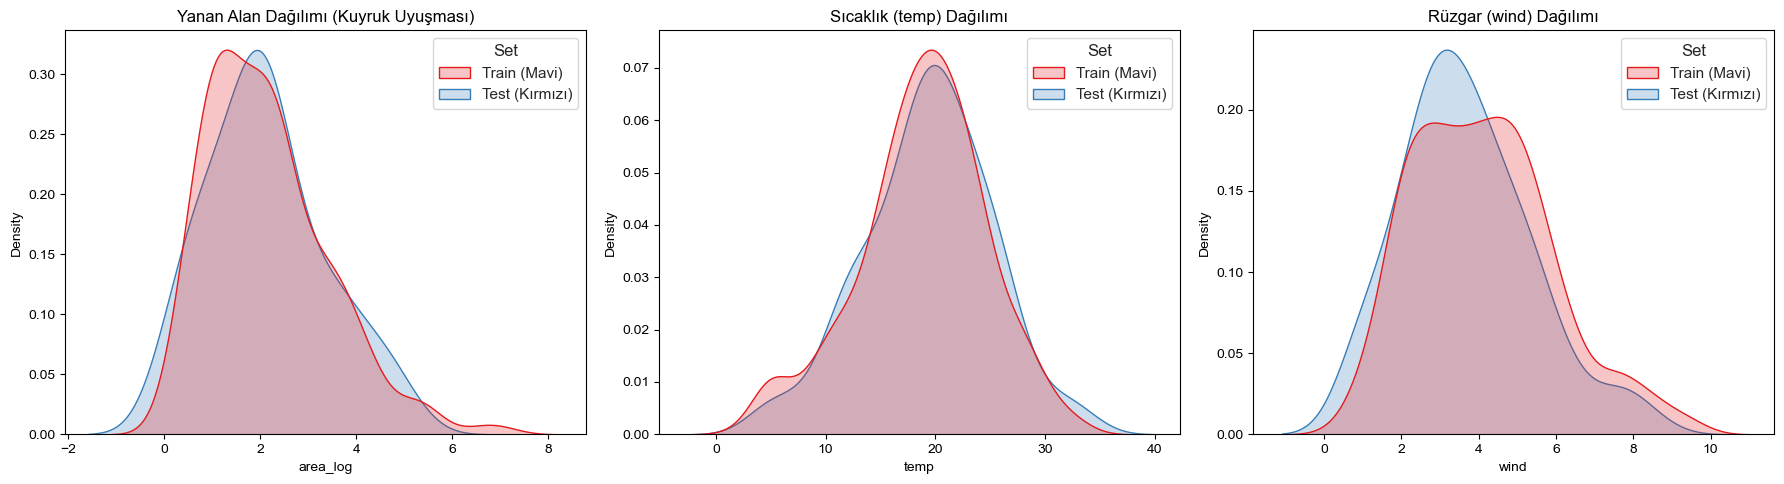

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

train_vis = X_train_strat.copy()
train_vis['Set'] = 'Train (Mavi)'

test_vis = X_test_strat.copy()
test_vis['Set'] = 'Test (Kırmızı)'

combined_vis = pd.concat([train_vis, test_vis])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

sns.kdeplot(data=combined_vis[combined_vis['area'] > 0], x='area_log', hue='Set', common_norm=False, fill=True, ax=axes[0], palette="Set1")
axes[0].set_title('Yanan Alan Dağılımı (Kuyruk Uyuşması)')

sns.kdeplot(data=combined_vis, x='temp', hue='Set', common_norm=False, fill=True, ax=axes[1], palette="Set1")
axes[1].set_title('Sıcaklık (temp) Dağılımı')

sns.kdeplot(data=combined_vis, x='wind', hue='Set', common_norm=False, fill=True, ax=axes[2], palette="Set1")
axes[2].set_title('Rüzgar (wind) Dağılımı')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict

drop_cols = ['area', 'area_log', 'daily_total_area', 'daily_total_area_log']
X_train_adv = X_train_strat.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
X_test_adv = X_test_strat.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])

y_adv = np.array([0] * len(X_train_adv) + [1] * len(X_test_adv))
X_adv = pd.concat([X_train_adv, X_test_adv]).reset_index(drop=True)

rf_detective = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

adv_preds = cross_val_predict(rf_detective, X_adv, y_adv, cv=5, method='predict_proba')[:, 1]

auc_score = roc_auc_score(y_adv, adv_preds)

print(f"ROC-AUC Skoru: {auc_score:.4f}")

if 0.45 <= auc_score <= 0.55:
    print("MUHTEŞEM! Yapay zeka Train ve Test'i birbirinden AYIRT EDEMEDİ. Bölünme kusursuz.")
elif auc_score > 0.60:
    print("TEHLİKE! Yapay zeka iki seti birbirinden ayırt edebiliyor. İklim/Dağılım kayması var.")
else:
    print("DENGELİ. Ufak farklılıklar var ama oldukça kabul edilebilir seviyede.")

ROC-AUC Skoru: 0.5430
MUHTEŞEM! Yapay zeka Train ve Test'i birbirinden AYIRT EDEMEDİ. Bölünme kusursuz.


=== PERMÜTASYON TESTİ KANIT RAPORU ===
Gerçek ROC-AUC Skorumuz: 0.5477
Hesaplanan İstatistiksel p-değeri: 0.1683
KANITLANDI: p > 0.05. Skorumuz rastgelelik sınırları içerisinde!


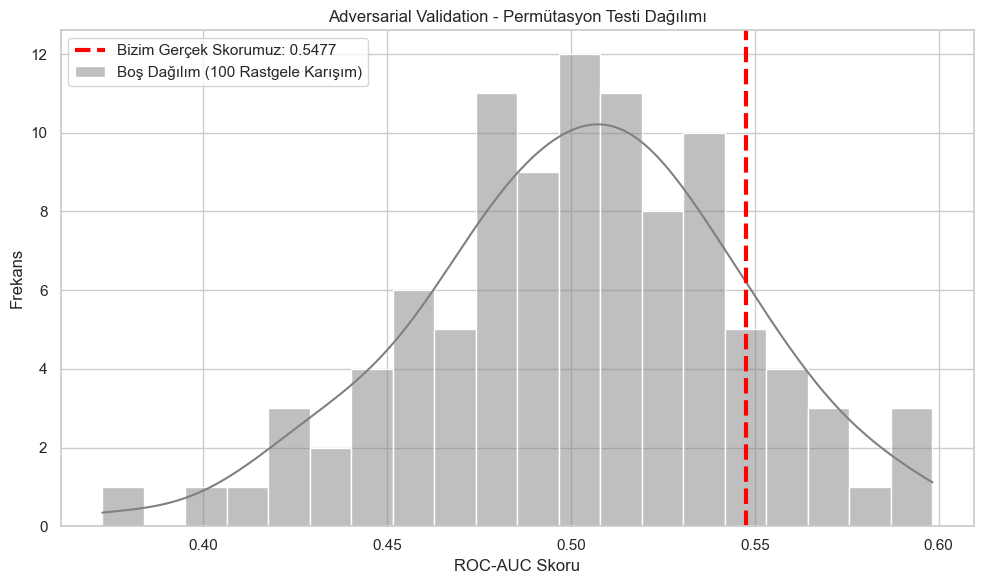

In [9]:
from sklearn.model_selection import permutation_test_score
from sklearn.ensemble import RandomForestClassifier

rf_detective = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

score, permutation_scores, pvalue = permutation_test_score(
    rf_detective, X_adv, y_adv, scoring="roc_auc", cv=5, n_permutations=100, random_state=42, n_jobs=-1
)

print(f"=== PERMÜTASYON TESTİ KANIT RAPORU ===")
print(f"Gerçek ROC-AUC Skorumuz: {score:.4f}")
print(f"Hesaplanan İstatistiksel p-değeri: {pvalue:.4f}")

if pvalue > 0.05:
    print("KANITLANDI: p > 0.05. Skorumuz rastgelelik sınırları içerisinde!")
else:
    print("DİKKAT: p <= 0.05. Skor tesadüf değil, veri setleri arasında sızıntı/fark var!")

plt.figure(figsize=(10, 6))
sns.histplot(permutation_scores, bins=20, kde=True, color="gray", label="Boş Dağılım (100 Rastgele Karışım)")
plt.axvline(score, color="red", linestyle="--", linewidth=3, label=f"Bizim Gerçek Skorumuz: {score:.4f}")

plt.title("Adversarial Validation - Permütasyon Testi Dağılımı")
plt.xlabel("ROC-AUC Skoru")
plt.ylabel("Frekans")
plt.legend()
plt.tight_layout()
plt.show()